# Actividad 1 — Interpretabilidad de modelos
**Análisis de Datos II · 4B2026**

En esta actividad analicé un Random Forest para predecir el salario anual en dólares (`salary_in_usd`) a partir de los datos de un puesto de trabajo. Mi objetivo fue interpretar y auditar sus predicciones mediante **PFI global y SHAP local**.

Primero entrené con todas las columnas predictoras, como pide la consigna. Después investigué la información duplicada del salario y comparé el modelo original con una versión corregida.

## Dataset
- [Dataset original de Kaggle, Arnab Chaki](https://www.kaggle.com/datasets/arnabchaki/data-science-salaries-2023). CSV descargado mediante la API pública de Kaggle y conservado en `datasets/ds_salaries.csv`.

In [1]:
from pathlib import Path
import sys
import hashlib
import importlib.metadata as metadata
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
from IPython.display import display, Markdown
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.dummy import DummyRegressor
from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

SEED = 42
plt.rcParams.update({'figure.figsize': (9, 5), 'axes.grid': True, 'grid.alpha': 0.2})
pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'datasets/ds_salaries.csv').exists())
DATA = ROOT / 'datasets/ds_salaries.csv'
print('Python:', sys.version.split()[0])
print({p: metadata.version(p) for p in ['numpy', 'pandas', 'scikit-learn', 'shap', 'matplotlib']})
print('SHA256 del CSV:', hashlib.sha256(DATA.read_bytes()).hexdigest())
df = pd.read_csv(DATA)
display(df.head())
print('Dimensiones:', df.shape)
print('Nulos:', int(df.isna().sum().sum()), '| Filas duplicadas adicionales:', int(df.duplicated().sum()))
assert 'salary_in_usd' in df and not df.isna().any().any()


Python: 3.12.13
{'numpy': '1.26.4', 'pandas': '2.3.3', 'scikit-learn': '1.9.1', 'shap': '0.49.1', 'matplotlib': '3.11.2'}
SHA256 del CSV: b156e54135634169cedc91c685851450d890a05f0753a2a655895e2475e946e6


,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2023,SE,FT,Principal Data Scientist,80000,EUR,85847,ES,100,ES,L
1,2023,MI,CT,ML Engineer,30000,USD,30000,US,100,US,S
2,2023,MI,CT,ML Engineer,25500,USD,25500,US,100,US,S
3,2023,SE,FT,Data Scientist,175000,USD,175000,CA,100,CA,M
4,2023,SE,FT,Data Scientist,120000,USD,120000,CA,100,CA,M


Dimensiones: (3755, 11)
Nulos: 0 | Filas duplicadas adicionales: 1171


## 1. Entrenamiento y evaluación inicial
Elegí `salary_in_usd` como variable objetivo y utilicé las otras diez columnas como predictoras. Codifiqué las categorías con one-hot para evitar imponerles un orden artificial. Ajusté el preprocesador **solo con los datos de entrenamiento**, dentro del pipeline, y no apliqué escalado porque el modelo está basado en árboles.

Reservé el 20 % de los datos para test y fijé la semilla en 42. En esta primera evaluación mantuve todas las filas, incluidos los duplicados, para analizar el dataset recibido; más adelante reviso cómo afecta su presencia a la separación entre entrenamiento y test. Usé `RandomForestRegressor(random_state=42)`, con los hiperparámetros de aprendizaje por defecto.

Evalué el modelo con MAE y RMSE, expresados en USD, y con R². Incluí RMSE para dar más peso a los errores grandes y agregué un predictor de la media de entrenamiento como referencia.

In [2]:
X = df.drop(columns='salary_in_usd')
y = df['salary_in_usd']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)

def crear_modelo(X_fit):
    cat = X_fit.select_dtypes(include=['object', 'string']).columns.tolist()
    num = [c for c in X_fit.columns if c not in cat]
    prep = ColumnTransformer([
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat),
        ('num', 'passthrough', num),
    ])
    return Pipeline([('prep', prep), ('rf', RandomForestRegressor(random_state=SEED))])

def metricas(real, pred):
    return {'MAE (USD)': mean_absolute_error(real, pred),
            'RMSE (USD)': np.sqrt(mean_squared_error(real, pred)),
            'R²': r2_score(real, pred)}

original = crear_modelo(X_train)
original.fit(X_train, y_train)
pred_original = original.predict(X_test)
dummy = DummyRegressor(strategy='mean').fit(X_train, y_train)
resultados = pd.DataFrame({
    'Referencia: media': metricas(y_test, dummy.predict(X_test)),
    'Original: train': metricas(y_train, original.predict(X_train)),
    'Original: test': metricas(y_test, pred_original),
}).T
display(resultados)
print(f'Train: {len(X_train)} filas; test: {len(X_test)} filas; predictores: {X.shape[1]}')


,MAE (USD),RMSE (USD),R²
Referencia: media,"48,917.756","62,878.335",-0.001
Original: train,659.025,"4,793.658",0.994
Original: test,"1,248.341","8,148.556",0.983


Train: 3004 filas; test: 751 filas; predictores: 10


**Mi interpretación del desempeño.** Obtuve un MAE de 1.248 USD en test, frente a 48.918 USD del predictor de la media, y un R² de 0,983. A primera vista, el resultado parece muy bueno. Sin embargo, el RMSE de 8.149 USD es bastante mayor que el MAE, lo que me indica que hay algunos errores grandes.

No considero suficiente esta evaluación para concluir que el modelo puede estimar un salario desconocido: todavía necesito revisar qué información está utilizando para conseguir ese desempeño.

## 2. Diagnóstico global: PFI
Calculé PFI sobre las columnas originales del **test**, con 10 repeticiones y R² como métrica, siguiendo el ejemplo de clase. Apliqué las permutaciones sobre el pipeline para evaluar cada variable completa, en lugar de interpretar sus dummies por separado.

Interpreto una PFI alta como una mayor dependencia del modelo respecto de esa variable, no como evidencia de causalidad. En los gráficos representé la desviación estándar entre permutaciones; no la interpreto como un intervalo de confianza. También tengo en cuenta que, cuando las variables están relacionadas, permutarlas por separado puede generar combinaciones poco realistas y alterar la importancia que observo.

,PFI (caída R²),DE
salary,1.913,0.080
salary_currency,0.442,0.033
employee_residence,0.001,0.000
company_location,0.001,0.000
work_year,0.000,0.000
job_title,0.000,0.000
company_size,0.000,0.000
experience_level,0.000,0.000
employment_type,0.000,0.000
remote_ratio,-0.000,0.001


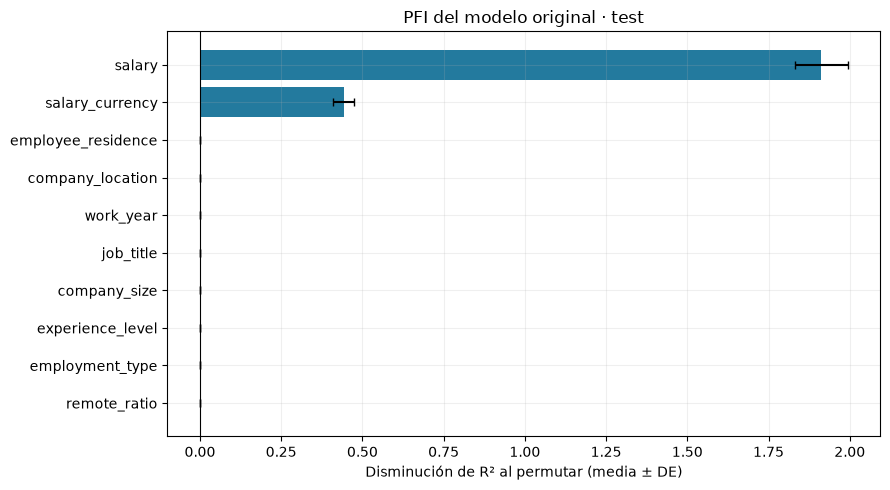

Observo que la variable dominante es **salary**, con caída de R² **1.913**. Le siguen **salary_currency** y **employee_residence**. Este resultado me lleva a investigar si estoy utilizando información duplicada del objetivo.

In [3]:
def calcular_pfi(modelo, datos, real):
    resultado = permutation_importance(modelo, datos, real, scoring='r2', n_repeats=10, random_state=SEED)
    return pd.DataFrame({'PFI (caída R²)': resultado.importances_mean,
                         'DE': resultado.importances_std}, index=datos.columns).sort_values('PFI (caída R²)', ascending=False)

def graficar_pfi(tabla, titulo, ax=None):
    if ax is None:
        _, ax = plt.subplots()
    tabla = tabla.sort_values('PFI (caída R²)')
    ax.barh(tabla.index, tabla['PFI (caída R²)'], xerr=tabla['DE'], color='#237a9e', capsize=3)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set(xlabel='Disminución de R² al permutar (media ± DE)', title=titulo)
    return ax

pfi_original = calcular_pfi(original, X_test, y_test)
display(pfi_original)
graficar_pfi(pfi_original, 'PFI del modelo original · test')
plt.tight_layout()
plt.show()
top = pfi_original.index[0]
display(Markdown(f'Observo que la variable dominante es **{top}**, con caída de R² **{pfi_original.iloc[0, 0]:.3f}**. '
                 f'Le siguen **{pfi_original.index[1]}** y **{pfi_original.index[2]}**. '
                 'Este resultado me lleva a investigar si estoy utilizando información duplicada del objetivo.'))


**Lo que me llamó la atención.** Encontré que `salary` domina el ranking con una PFI de 1,913, seguida por `salary_currency` con 0,442. Las demás variables tienen importancias muy pequeñas en este modelo. Esto me lleva a investigar si el bosque está reconstruyendo el salario en USD a partir de un monto ya conocido, en lugar de aprender principalmente de la experiencia o del puesto.

La caída de R² puede superar 1 porque esta métrica no tiene cota inferior: al permutar `salary`, pasa aproximadamente de 0,983 a −0,930. Por eso no leo estos valores como porcentajes de importancia. Tampoco concluyo que experiencia o puesto sean irrelevantes para los salarios a partir de su baja PFI en este bosque.

## 3. Diagnóstico local: dos predicciones distintas con SHAP
Seleccioné las observaciones con menor y mayor predicción del test, **sin usar sus errores para elegirlas**. Las uso para contrastar dos comportamientos del modelo, aunque reconozco que estos extremos no representan todo el dataset.

Utilicé TreeExplainer con `tree_path_dependent`, cuya referencia se obtiene de los conteos de entrenamiento de los árboles. Para comparar las explicaciones con PFI, sumé los SHAP de las dummies por variable original y comprobé que el valor base más las contribuciones reconstruye cada predicción. Esta suma conserva la aditividad, pero no equivale a recalcular Shapley con coaliciones de variables agrupadas.

Leo los aportes positivos como aumentos de la predicción respecto del valor base y los negativos como reducciones. Estoy explicando la salida del modelo, no las causas del salario real de cada persona.

,work_year,experience_level,employment_type,job_title,salary,salary_currency,employee_residence,remote_ratio,company_location,company_size,real_USD,prediccion_USD,error_absoluto_USD
573,2023,EN,FT,Autonomous Vehicle Technician,7000,USD,GH,0,GH,S,7000,"7,697.220",697.220
2359,2022,SE,FT,Data Science Tech Lead,375000,USD,US,50,US,L,375000,"379,113.610","4,113.610"


### Predicción baja · fila 573

,valor observado,SHAP (USD)
salary,7000,"-130,828.766"
salary_currency,USD,"1,215.943"
company_size,S,-484.955
experience_level,EN,-206.981
work_year,2023,-17.800
employee_residence,GH,15.135
job_title,Autonomous Vehicle Technician,12.598
employment_type,FT,11.111
remote_ratio,0,-10.366
company_location,GH,0.002


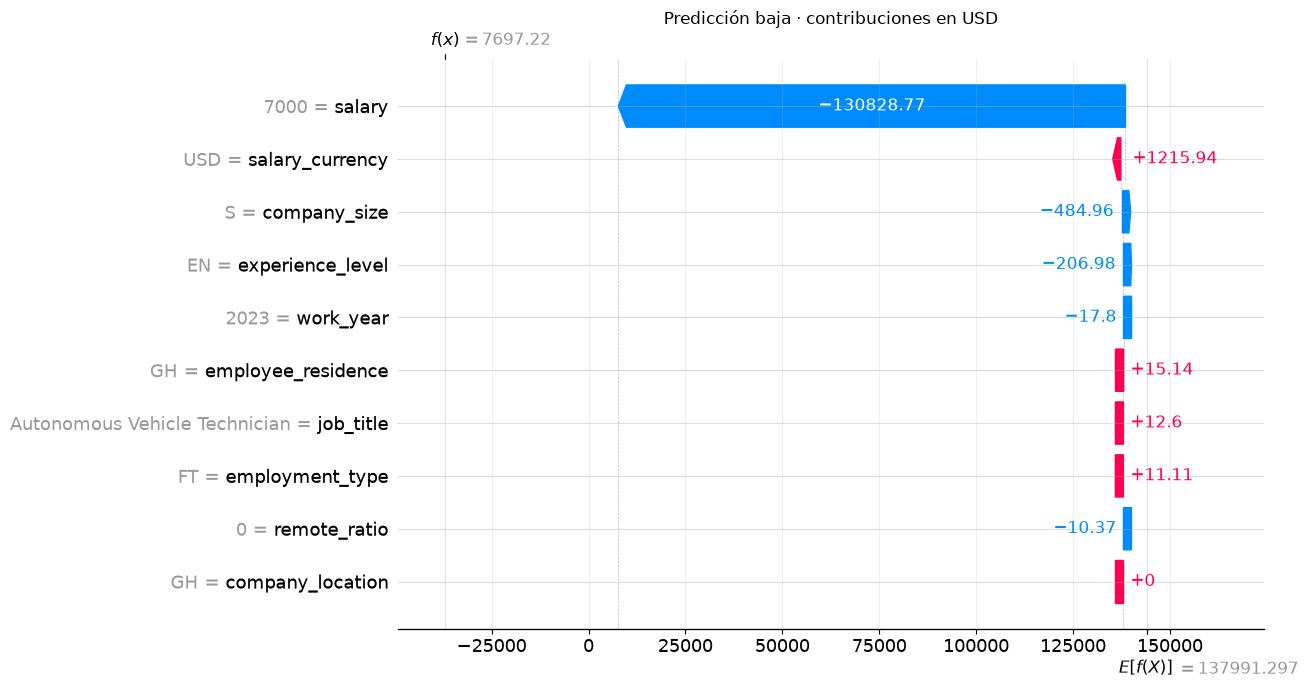

En este caso observo que **salary=7000** reduce la predicción en **130,829 USD**; **salary_currency=USD** aumenta la predicción en **1,216 USD**; **company_size=S** reduce la predicción en **485 USD**. Valor base: **137,991 USD**; predicción: **7,697 USD**; salario real: **7,000 USD**. Identifico a **salary** como la variable más influyente en este caso y a **salary** como la más importante en PFI. No comparo directamente sus magnitudes: con PFI evalúo la pérdida de desempeño promedio y con SHAP explico una predicción individual.

### Predicción alta · fila 2359

,valor observado,SHAP (USD)
salary,375000,"232,897.272"
salary_currency,USD,"9,521.519"
experience_level,SE,"-2,154.138"
company_size,L,533.261
employee_residence,US,200.725
company_location,US,179.537
job_title,Data Science Tech Lead,-167.013
work_year,2022,136.773
remote_ratio,50,-98.529
employment_type,FT,72.906


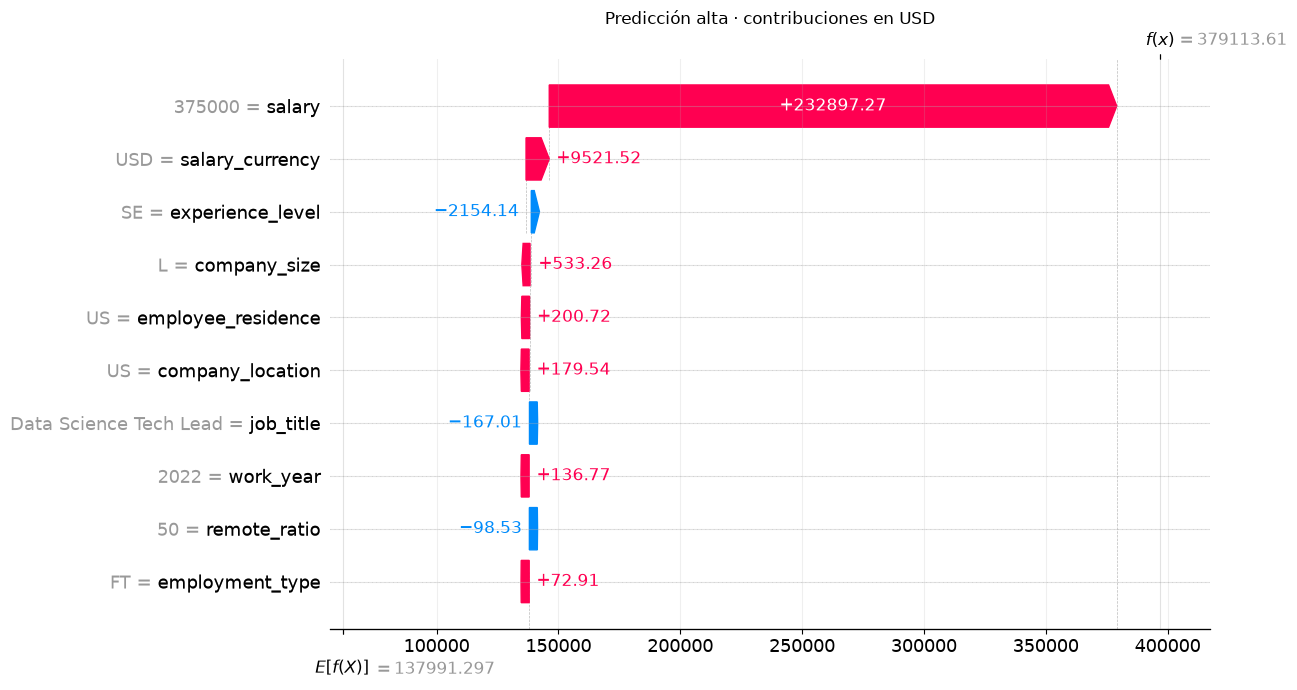

En este caso observo que **salary=375000** aumenta la predicción en **232,897 USD**; **salary_currency=USD** aumenta la predicción en **9,522 USD**; **experience_level=SE** reduce la predicción en **2,154 USD**. Valor base: **137,991 USD**; predicción: **379,114 USD**; salario real: **375,000 USD**. Identifico a **salary** como la variable más influyente en este caso y a **salary** como la más importante en PFI. No comparo directamente sus magnitudes: con PFI evalúo la pérdida de desempeño promedio y con SHAP explico una predicción individual.

In [4]:
posiciones = [int(np.argmin(pred_original)), int(np.argmax(pred_original))]
casos = X_test.iloc[posiciones]
prep = original.named_steps['prep']
transformados = prep.transform(casos)
explainer = shap.TreeExplainer(original.named_steps['rf'], feature_perturbation='tree_path_dependent')
exp = explainer(transformados, check_additivity=True)

# Recupero el orden de las columnas transformadas para agrupar los aportes por variable original.
cat = prep.transformers_[0][2]
num = prep.transformers_[1][2]
propietarios = [c for c, categorias in zip(cat, prep.named_transformers_['cat'].categories_) for _ in categorias] + list(num)
assert len(propietarios) == exp.values.shape[1]
agrupados = np.column_stack([exp.values[:, np.array(propietarios) == c].sum(axis=1) for c in X.columns])
base = np.asarray(exp.base_values).reshape(-1)
np.testing.assert_allclose(base + agrupados.sum(axis=1), original.predict(casos), atol=1e-5)

resumen_casos = casos.copy()
resumen_casos['real_USD'] = y_test.loc[casos.index]
resumen_casos['prediccion_USD'] = pred_original[posiciones]
resumen_casos['error_absoluto_USD'] = abs(resumen_casos.real_USD - resumen_casos.prediccion_USD)
display(resumen_casos)
for j, etiqueta in enumerate(['Predicción baja', 'Predicción alta']):
    display(Markdown(f'### {etiqueta} · fila {casos.index[j]}'))
    tabla = pd.DataFrame({'valor observado': casos.iloc[j].astype(str), 'SHAP (USD)': agrupados[j]}, index=X.columns)
    tabla = tabla.loc[tabla['SHAP (USD)'].abs().sort_values(ascending=False).index]
    display(tabla)
    explicacion = shap.Explanation(values=agrupados[j], base_values=float(base[j]),
                                   data=casos.iloc[j].astype(str).values, feature_names=list(X.columns))
    shap.plots.waterfall(explicacion, max_display=10, show=False)
    fig = plt.gcf()
    fig.set_size_inches(13, 7)
    ax = fig.axes[0]
    izquierda, derecha = ax.get_xlim()
    margen = (derecha - izquierda) * 0.30
    ax.set_xlim(izquierda - margen, derecha + margen * 0.3)
    plt.title(f'{etiqueta} · contribuciones en USD')
    plt.tight_layout()
    plt.show()
    frases = [f"**{v}={casos.iloc[j][v]}** {'aumenta' if tabla.loc[v, 'SHAP (USD)'] > 0 else 'reduce'} la predicción en **{abs(tabla.loc[v, 'SHAP (USD)']):,.0f} USD**" for v in tabla.index[:3]]
    display(Markdown('En este caso observo que ' + '; '.join(frases) + f". Valor base: **{base[j]:,.0f} USD**; predicción: **{pred_original[posiciones[j]]:,.0f} USD**; salario real: **{y_test.iloc[posiciones[j]]:,.0f} USD**. "
        + f"Identifico a **{tabla.index[0]}** como la variable más influyente en este caso y a **{pfi_original.index[0]}** como la más importante en PFI. "
        + 'No comparo directamente sus magnitudes: con PFI evalúo la pérdida de desempeño promedio y con SHAP explico una predicción individual.'))


**Mi interpretación de los dos casos.** En la fila 573, el modelo predijo 7.697 USD frente a un salario real de 7.000 USD. Observé que `salary=7000` reduce la predicción en 130.829 USD respecto del valor base, mientras que la moneda USD aporta +1.216 USD y el tamaño de empresa S aporta −485 USD.

En la fila 2359, la predicción fue de 379.114 USD frente a 375.000 USD reales. En este caso, `salary=375000` aporta +232.897 USD y la moneda USD suma +9.522 USD. En ambos casos encontré que domina `salary`, en acuerdo con el diagnóstico global, aunque su contribución cambia de dirección.

Me llamó la atención el aporte de −2.154 USD de `experience_level=SE` en el caso alto. No lo interpreto como que ser senior reduzca causalmente el salario: es un aporte local respecto de la referencia de un modelo que utiliza información del salario. Antes de sacar una conclusión sobre experiencia, revisaría más casos con el modelo corregido.

## 4. Auditoría: evidencia y causas posibles
### 4.1. Información duplicada del objetivo
Planteé el problema como la estimación del salario **antes de conocer el monto acordado**. Al revisar las columnas, identifiqué que `salary` contiene ese monto en moneda original y `salary_in_usd` lo expresa en USD. Por eso considero que incluir `salary` introduce fuga de información del objetivo en este escenario.

Para comprobarlo, revisé la igualdad entre ambos montos en las filas con moneda USD y calculé el cociente `salary_in_usd / salary` por moneda y año. Utilicé ese cociente únicamente como control de auditoría; no lo incorporé al modelo.

Encontré igualdad en las 3.224 filas con moneda USD, que representan el 85,9 % del dataset. Además, las tasas implícitas de los grupos mostrados son estables a la precisión de la tabla. Esta evidencia, junto con PFI y SHAP, sustenta mi diagnóstico de leakage; no lo baso solamente en una importancia alta.

In [5]:
usd = df.salary_currency.eq('USD')
print(f'Filas en USD: {usd.sum()} / {len(df)} ({usd.mean():.1%})')
print(f'Igualdad salary == salary_in_usd en USD: {np.isclose(df.loc[usd, "salary"], df.loc[usd, "salary_in_usd"]).mean():.1%}')
auditoria = df.assign(tasa_implicita=df.salary_in_usd / df.salary)
tasas = auditoria.groupby(['salary_currency', 'work_year']).agg(
    n=('salary', 'size'), tasa_media=('tasa_implicita', 'mean'),
    tasa_min=('tasa_implicita', 'min'), tasa_max=('tasa_implicita', 'max'))
display(tasas.sort_values('n', ascending=False).head(15))
print('Residencia igual a ubicación de empresa:', f'{df.employee_residence.eq(df.company_location).mean():.1%}')
hashes = pd.util.hash_pandas_object(df, index=False)
solapadas = hashes.loc[X_test.index].isin(hashes.loc[X_train.index])
print(f'Filas de test idénticas a alguna de train: {solapadas.sum()} / {len(X_test)} ({solapadas.mean():.1%})')


Filas en USD: 3224 / 3755 (85.9%)
Igualdad salary == salary_in_usd en USD: 100.0%


n  tasa_media  tasa_min  tasa_max
salary_currency work_year                                      
USD             2023       1646       1.000     1.000     1.000
                2022       1418       1.000     1.000     1.000
                2021        122       1.000     1.000     1.000
EUR             2022        115       1.051     1.051     1.051
GBP             2022         83       1.231     1.231     1.231
                2023         62       1.215     1.215     1.215
EUR             2023         53       1.073     1.073     1.073
                2021         44       1.182     1.182     1.182
USD             2020         38       1.000     1.000     1.000
EUR             2020         24       1.140     1.140     1.140
INR             2021         23       0.014     0.014     0.014
                2022         20       0.013     0.013     0.013
GBP             2021         13       1.375     1.375     1.375
CAD             2022         11       0.768     0.768     0.768
INR             2023         11       0.012     0.012     0.012

Residencia igual a ubicación de empresa: 97.4%
Filas de test idénticas a alguna de train: 307 / 751 (40.9%)


### Hallazgos y acciones

| Hallazgo | Evidencia que observé | Mi interpretación y posible causa | Acción que tomé o propongo |
|---|---|---|---|
| Fuga por `salary` | PFI = 1,913; mayor aporte absoluto en los dos casos SHAP; igualdad con el target en todas las filas USD. | Considero que el modelo aprovecha dos representaciones del mismo monto. Es razonable para convertir un salario conocido, pero no para estimarlo antes de conocerlo. | Eliminé `salary` y reentrené con el mismo split para comparar métricas y PFI. |
| Papel de `salary_currency` | Obtuve PFI = 0,442 en el modelo original y comprobé su relación con las tasas de conversión. | Interpreto que ayuda a convertir el monto y también puede representar el mercado laboral. Supuse que la moneda se conoce antes de estimar el salario; por sí sola no duplica el target. | La conservé en la corrección principal y probé además un modelo sin ella. Antes de usar el modelo, verificaría su disponibilidad real. |
| Redundancia geográfica | Encontré que residencia y ubicación de empresa coinciden en el 97,4 % de las filas. | Me parece plausible trabajar en el país de residencia. Considero que una variable puede sustituir parte de la información de la otra, por lo que no interpreto una PFI baja como ausencia de información útil. | Permuté ambas variables juntas en el modelo corregido. No interpreto sus aportes como efectos causales de cambiar de país. |
| Solapamiento de duplicados | Identifiqué 307 filas de test con una copia exacta en entrenamiento. | Puede tratarse de registros repetidos o de personas con los mismos atributos y salario. Sin identificadores, no puedo distinguir ambas posibilidades; PFI y SHAP tampoco resuelven esa duda. | Hice una evaluación adicional separando grupos de filas idénticas y analicé sus resultados por separado. |
| Alcance de SHAP local | Expliqué únicamente los extremos de predicción; por ejemplo, observé un aporte negativo de SE en el caso alto. | No considero que dos casos permitan establecer reglas generales sobre los salarios. Los aportes dependen del contexto de cada observación. | Como siguiente paso, ampliaría los casos, revisaría errores por subgrupo y evaluaría datos de un período posterior. |

## 5. Corrección del leakage y comparación
En la comparación principal eliminé **solo `salary`**. Mantuve el mismo test, la semilla y la configuración del bosque para aislar este cambio. También entrené una variante sin `salary_currency` para revisar la sensibilidad a mi supuesto de que la moneda se conoce al predecir. No hice búsqueda de hiperparámetros.

,MAE (USD),RMSE (USD),R²
Referencia: media,"48,917.756","62,878.335",-0.001
Original,"1,248.341","8,148.556",0.983
Sin salary,"36,527.090","48,783.188",0.397
Sin salary ni moneda,"36,418.418","48,687.233",0.400


,PFI (caída R²) original,DE original,PFI (caída R²) corregido,DE corregido
company_location,0.001,0.000,0.003,0.002
company_size,0.000,0.000,0.012,0.005
employee_residence,0.001,0.000,0.285,0.021
employment_type,0.000,0.000,0.000,0.000
experience_level,0.000,0.000,0.181,0.020
job_title,0.000,0.000,0.152,0.022
remote_ratio,-0.000,0.001,0.024,0.008
salary,1.913,0.080,NaN,NaN
salary_currency,0.442,0.033,0.080,0.007
work_year,0.000,0.000,0.024,0.009


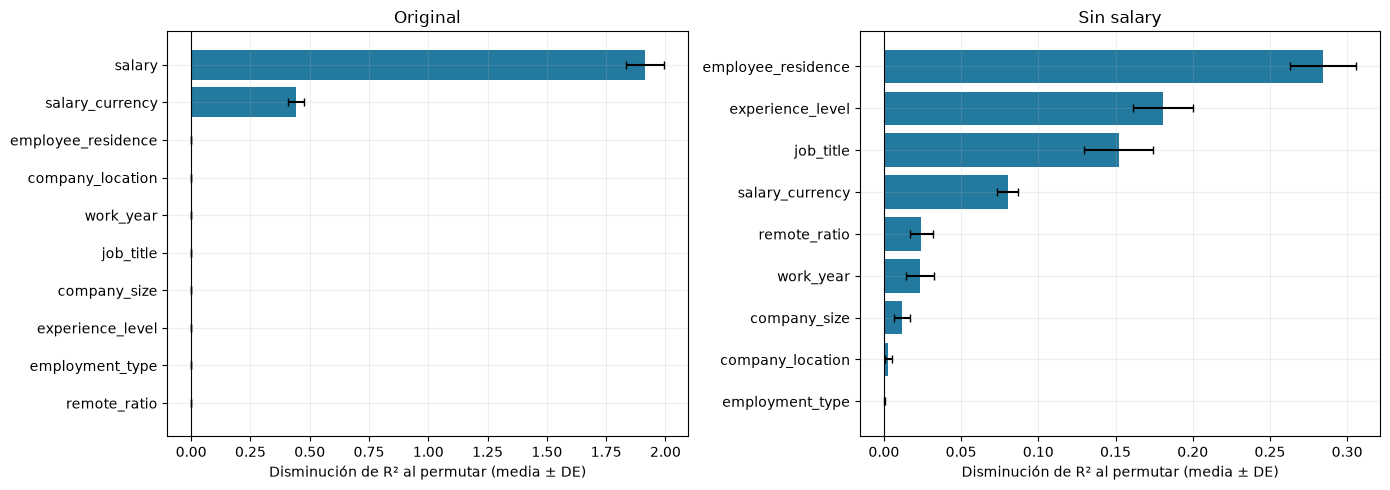

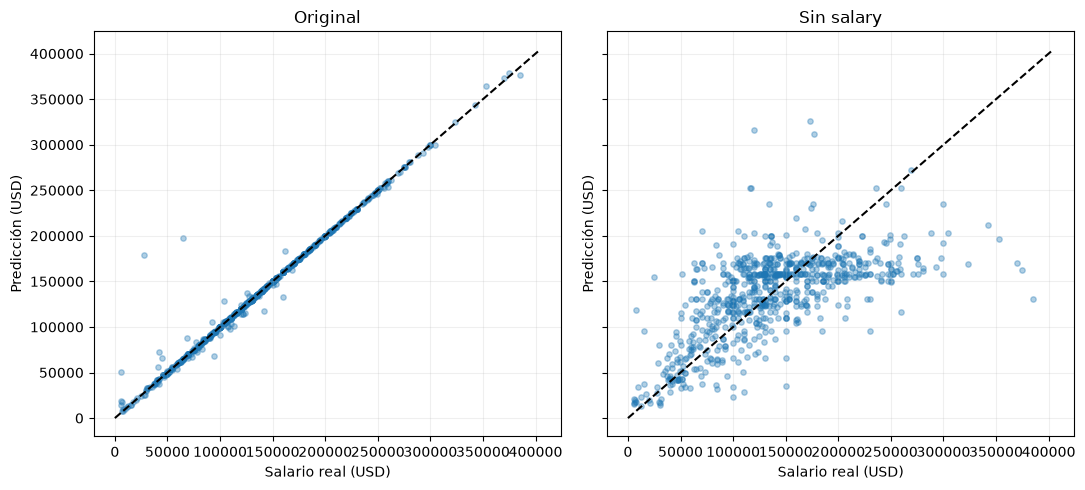

Al retirar `salary`, obtuve un cambio de R² de **0.983** a **0.397**, y MAE de **1,248** a **36,527 USD**. Identifiqué como principales variables del modelo corregido a **employee_residence, experience_level, job_title**. Con esta comparación observo cuánto dependía el desempeño de conocer el salario original. Considero que el modelo corregido se ajusta mejor al problema porque utiliza atributos del puesto y del contexto laboral, aunque tendría que evaluar si su error es aceptable antes de aplicarlo.

In [6]:
X_train_limpio = X_train.drop(columns='salary')
X_test_limpio = X_test.drop(columns='salary')
corregido = crear_modelo(X_train_limpio)
corregido.fit(X_train_limpio, y_train)
pred_corregido = corregido.predict(X_test_limpio)
sin_moneda = crear_modelo(X_train_limpio.drop(columns='salary_currency'))
sin_moneda.fit(X_train_limpio.drop(columns='salary_currency'), y_train)
comparacion = pd.DataFrame({
    'Referencia: media': metricas(y_test, dummy.predict(X_test)),
    'Original': metricas(y_test, pred_original),
    'Sin salary': metricas(y_test, pred_corregido),
    'Sin salary ni moneda': metricas(y_test, sin_moneda.predict(X_test_limpio.drop(columns='salary_currency'))),
}).T
display(comparacion)
pfi_corregido = calcular_pfi(corregido, X_test_limpio, y_test)
display(pfi_original.add_suffix(' original').join(pfi_corregido.add_suffix(' corregido'), how='outer'))
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
graficar_pfi(pfi_original, 'Original', axes[0])
graficar_pfi(pfi_corregido, 'Sin salary', axes[1])
plt.tight_layout()
plt.show()
fig, axes = plt.subplots(1, 2, figsize=(11, 5), sharex=True, sharey=True)
limites = [0, max(y_test.max(), pred_original.max(), pred_corregido.max()) * 1.05]
for ax, pred, titulo in zip(axes, [pred_original, pred_corregido], ['Original', 'Sin salary']):
    ax.scatter(y_test, pred, alpha=0.35, s=15)
    ax.plot(limites, limites, '--', color='black')
    ax.set(title=titulo, xlabel='Salario real (USD)', ylabel='Predicción (USD)')
plt.tight_layout()
plt.show()
display(Markdown(f"Al retirar `salary`, obtuve un cambio de R² de **{comparacion.loc['Original', 'R²']:.3f}** a **{comparacion.loc['Sin salary', 'R²']:.3f}**, "
    f"y MAE de **{comparacion.loc['Original', 'MAE (USD)']:,.0f}** a **{comparacion.loc['Sin salary', 'MAE (USD)']:,.0f} USD**. "
    f"Identifiqué como principales variables del modelo corregido a **{', '.join(pfi_corregido.index[:3])}**. "
    'Con esta comparación observo cuánto dependía el desempeño de conocer el salario original. Considero que el modelo corregido se ajusta mejor al problema porque utiliza atributos del puesto y del contexto laboral, aunque tendría que evaluar si su error es aceptable antes de aplicarlo.'))


**Mi interpretación después de corregir el modelo.** Al quitar `salary`, obtuve R² = 0,397 y MAE = 36.527 USD. El error sigue siendo menor que los 48.918 USD de la referencia, pero lo considero considerable. En el gráfico observo mayor dispersión y subestimación de varios salarios altos.

Las variables que ahora encabezan PFI son residencia (0,285), experiencia (0,181) y puesto (0,152). Este comportamiento me resulta más coherente con estimar un salario a partir de características del trabajo y del mercado, aunque no demuestra causalidad ni ausencia de sesgos.

Al quitar también la moneda obtuve R² = 0,400 y MAE = 36.418 USD. No considero que esta diferencia pequeña, medida en un único split, permita afirmar que la variante es superior. Tampoco veo una contradicción entre la PFI de moneda de 0,080 y el escaso cambio al quitarla y reentrenar: en PFI evalúo el mismo bosque, mientras que un nuevo bosque puede usar variables sustitutas.

### Controles complementarios: dependencia geográfica y duplicados
Para revisar la dependencia geográfica, permuté residencia y ubicación con **el mismo orden de filas**, conservando la relación entre ambas. Comparé esta PFI conjunta con la suma de las individuales, teniendo en cuenta que no tienen por qué coincidir.

Después repetí la evaluación separando grupos de filas completas idénticas. Utilicé la igualdad del target solo para identificar esos duplicados, no como predictor. Como el nuevo test tiene otra composición y puede contener una proporción de filas distinta del 20 %, considero esta prueba un control de sensibilidad y no una comparación pareada con el split inicial.

In [7]:
rng = np.random.default_rng(SEED)
score_base = r2_score(y_test, pred_corregido)
caidas = []
geo = ['employee_residence', 'company_location']
for _ in range(10):
    perm = X_test_limpio.copy()
    perm.loc[:, geo] = X_test_limpio.iloc[rng.permutation(len(perm))][geo].to_numpy()
    caidas.append(score_base - r2_score(y_test, corregido.predict(perm)))
print(f'PFI conjunta geográfica: {np.mean(caidas):.4f} ± {np.std(caidas):.4f}')
print(f'Suma de PFI individuales: {pfi_corregido.loc[geo, "PFI (caída R²)"].sum():.4f}')

gtrain, gtest = next(GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED).split(X, y, groups=hashes))
assert set(hashes.iloc[gtrain]).isdisjoint(set(hashes.iloc[gtest]))
Xg = X.drop(columns='salary')
modelo_grupos = crear_modelo(Xg.iloc[gtrain])
modelo_grupos.fit(Xg.iloc[gtrain], y.iloc[gtrain])
dummy_grupos = DummyRegressor().fit(Xg.iloc[gtrain], y.iloc[gtrain])
display(pd.DataFrame({
    'Sin salary, split original': metricas(y_test, pred_corregido),
    'Sin salary, grupos sin solapamiento': metricas(y.iloc[gtest], modelo_grupos.predict(Xg.iloc[gtest])),
    'Media, grupos sin solapamiento': metricas(y.iloc[gtest], dummy_grupos.predict(Xg.iloc[gtest])),
}).T)
print(f'Split por grupos: {len(gtrain)} filas de train y {len(gtest)} de test; cero duplicados exactos compartidos.')


PFI conjunta geográfica: 0.3019 ± 0.0194
Suma de PFI individuales: 0.2874


,MAE (USD),RMSE (USD),R²
"Sin salary, split original","36,527.090","48,783.188",0.397
"Sin salary, grupos sin solapamiento","35,117.516","48,562.127",0.372
"Media, grupos sin solapamiento","45,450.310","61,285.099",-0.000


Split por grupos: 3037 filas de train y 718 de test; cero duplicados exactos compartidos.


**Mi interpretación de los controles.** Obtuve una PFI conjunta geográfica de 0,302, frente a 0,287 al sumar las individuales. Esto me indica que el modelo depende de ese bloque de información, pero no uso la diferencia para cuantificar por sí sola la redundancia. La coincidencia del 97,4 % entre las columnas es la evidencia directa que encontré de su similitud.

En la separación inicial, 307 de las 751 filas de test (40,9 %) tienen una copia exacta en entrenamiento. Al separar grupos idénticos, obtuve R² = 0,372 y MAE = 35.118 USD para el modelo sin `salary`, frente a 0,397 y 36.527 USD en el split original.

Como cambió la composición del test, no atribuyo toda la diferencia a los duplicados ni concluyo que el modelo mejoró solo porque bajó el MAE. Con este control eliminé el solapamiento de filas exactas y seguí observando un desempeño moderado. No puedo descartar que haya registros de una misma persona con datos diferentes.

## 6. Conclusiones

1. **Identifiqué una fuga de información en `salary`.** El modelo original alcanzó R² = 0,983, pero PFI y los dos casos SHAP mostraron que dependía principalmente de esa columna. La igualdad de montos en USD y las tasas por moneda y año respaldan que estaba usando otra representación del objetivo.
2. **Al corregir la fuga obtuve una evaluación más acorde con el problema.** Sin `salary`, R² bajó a 0,397 y MAE aumentó a 36.527 USD. Interpreto esa caída como evidencia de cuánto ayudaba conocer el salario original. Residencia, experiencia y puesto pasaron a encabezar la importancia del bosque corregido.
3. **También encontré aspectos que requieren cuidado al evaluar.** La coincidencia entre las variables geográficas limita mi lectura de sus PFI individuales. Además, detecté duplicados compartidos entre train y test y realicé un control por grupos para evitar ese solapamiento exacto.
4. **Reconozco las limitaciones del análisis.** No hice validación temporal ni puedo garantizar que el dataset represente al mercado laboral. Usé el test para los diagnósticos de la actividad; si continuara seleccionando modelos, reservaría otro conjunto independiente para la evaluación final. Las repeticiones de PFI miden variación entre permutaciones y los dos casos SHAP no resumen toda la población. Mantuve los hiperparámetros por defecto, como solicita la consigna.

A partir de esta actividad, concluyo que una métrica alta no basta para confiar en un modelo: necesito revisar qué información utiliza y si estará disponible cuando quiera hacer una predicción.